# GDL - Midterm n.1
**Student ID: 660903** (Your student "matricola" goes here)

**Submission ID: 10** (The ID from the sheet circulated in classroom goes here)

In the first midterm assignment, you are required to implement a Gaussian Mixture Model (GMM) and the Expectation-Maximization (EM) algorithm. You are allowed to use `numpy` and other non-machine learning libraries, e.g., `pandas`, `matplotlib`.

**Assumptions.** To ease the implementation, we assume, for each Gaussian distribution in the mixture $\mathcal{N}(\mu_k, \Sigma_k)$, that the *covariance matrix is diagonal*. Furthermore, keep in mind that a good implementation of the EM algorithm provides monotonically increasing log-likelihood, *but* can get stuck in local minima; initialization strategies are fundamental (random? sample points? k-means++?).

**Hyperparameter $k$.** When using a GMM, you should ask yourself: *how many mixtures will be in the data?* You can *maximize* the Bayesian Information Criterion (BIC) to select the number of categories $k$ on your training set. Formally,
$$
\text{BIC}
=
\log P(X\mid \theta) - \frac{|\theta|}{2}\log n,
$$
where $n$ is the number of samples in the training set, $\theta=\{\pi,\mu,\sigma\}$ the parameters of the GMM and $|\theta|$ the number of parameters, i.e., the sum of the number of parameters in $\pi$, $\mu$, and $\sigma$ (*hint*: it also depends on the dimensionality of data $d$!).

**Summary.** Overall, you are required to:
1.  **Implement the GMM class**. Fill the `log_likelihood(samples)`.
2. **Implement the EM algorithm**. Fill the `fit(samples)` method to fit the parameters of a GMM.
3. **Implement the BIC score**. Fill the `bic(samples)` method to perform model selection.
4. **Run training and evaluation**. Select the best scoring model using BIC (Bayesian Information Criterion) for values of $k=\{1,\ldots,6\}$.

**Evaluation.** Your solution will be tested against an hidden test set. For your learning experience, we require you to refrain from using LLM generated code. Violations will be flagged and invalidate the midterm. **Do not alter Sections 3 and 4 of the notebook.**

### 1. Libraries

In [6]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    
print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Gaussian Mixture Model (GMM)

Feel free to play around the implementation. **For evaluation purposes**, the class **must** expose the following attributes and methods:
- `_pi: np.ndarray`
- `_mu: np.ndarray`
- `_sigma: np.ndarray`
- `fit(samples: np.ndarray)`
- `bic(samples: np.ndarray) -> np.ndarray`
- `log_likelihood(samples: np.ndarray) -> np.ndarray`

In [7]:
class GaussianMixtureModel:
    def __init__(self, n_categories: int, n_features: int):
        self.n_categories = n_categories
        self.n_features = n_features
        self._ll_history = []
            
        # Choose a smart initialization strategy for the parameters!
        # weights (pi), means (mu), covariances (sigma)
        # NOTE: for the covariance, you can store only the diagonal
        
        self._pi = None # (k,)
        self._mu = None # (k, d)
        self._sigma = None # (k, d)
    
    
    def _initialize_parameters(self, samples: np.ndarray):
        """
        Parameters initialization data-driven
        """
        n = samples.shape[0]
        
        # mu = k random points in the dataset
        idx = np.random.choice(n, size=self.n_categories, replace=False)
        self._mu = samples[idx].copy()

        # sigma = global variance of the dataset
        self._sigma = np.tile(np.var(samples, axis=0), (self.n_categories, 1)) 
        self._sigma = np.clip(self._sigma, 1e-6, None)

        # pi = uniform 
        self._pi = np.ones(self.n_categories) / self.n_categories           

    def _mixture_density(self, samples: np.ndarray):
        """
        Compute the weighted_pdf P(x_i|z=k) * pi_k and mixture_density sum_k P(x_i|z=k) * pi_k
        """

        # P(x_i|z=k)
        pdf = self._gaussian_pdf(samples) # (n,k)
        
        # P(x_i|z=k) * pi_k 
        weighted_pdf = pdf * self._pi  # (n, k)
        
        # sum_k P(x_i|z=k) * pi_k
        mixture_density = np.sum(weighted_pdf, axis=1, keepdims=True) # (n,1)
        
        # numerical stability
        mixture_density = np.clip(mixture_density, 1e-15, None)

        return weighted_pdf, mixture_density

    def _gaussian_pdf(self, samples: np.ndarray):
        """
        Compute multivariate gaussian pdf with diagonal covariance N(x_i | mu_k, diag(sigma_k))
        as product of univariate gaussians N(x_ij | mu_kj, sigma_kj)
        """
        n_samples = samples.shape[0] # n
        pdf = np.zeros((n_samples, self.n_categories)) # (n, k)

        for k in range(self.n_categories):

            # (x_i - mu_k)
            diff = samples - self._mu[k] # (n, d)

            # -0.5 * (x_ij - mu_kj)^2 / sigma_kj
            exponent = -0.5 * (diff**2 / self._sigma[k]) # (n, d)

            # 1 / sqrt(2 * pi * sigma_kj)
            normalization = 1.0 / np.sqrt(2 * np.pi * self._sigma[k]) # (d,)
            
            # N(x_ij | mu_kj, sigma_kj) for each feature j
            univariate_pdfs = normalization * np.exp(exponent) # (n,d)

            # prod_j N(x_ij | mu_kj, sigma_kj) = N(x_i | mu_k, diag(sigma_k))
            pdf[:, k] = np.prod(univariate_pdfs, axis=1) # (n,)
            
        return pdf # (n, k)

    def log_likelihood(self, samples: np.ndarray) -> np.ndarray:
        """
        Compute logP(X|θ) = sum_i log( sum_k p(x_i|z=k) * pi_k )
        """
        # sum_k (P(x_i | z=k) * pi_k)
        _, mixture_density = self._mixture_density(samples) # (n,1)
        
        # sum_i (log( sum_k p(x_i|z=k) * pi_k )
        return np.array(np.sum(np.log(mixture_density))) # scalar

    def fit(self, samples: np.ndarray, max_iter=100, tol=1e-4):
        """
        Fits the GMM parameters using the EM algorithm
        """

        self._initialize_parameters(samples)

        n = samples.shape[0]
        prev_ll = -np.inf
        self._ll_history = []

        for _ in range(max_iter):

            # E-STEP 
            
            # P(x_i|z=k) * pi_k, sum_k (P(x_i|z=k) * pi_k)
            weighted_pdf, mixture_density = self._mixture_density(samples)
            
            # P(z=k|x_i) = P(x_i|z=k) * pi_k / sum_k (P(x_i|z=k) * pi_k)
            resp = weighted_pdf / mixture_density # (n,k)

            # M-STEP 

            # sum_i (P(z=k|x_i))
            N_k = resp.sum(axis=0)  # (k,)

            # numerical stability
            N_k = np.clip(N_k, 1e-15, None)

            # update pi_k = N_k / n
            self._pi = N_k / n  # (k,)
            
            for k in range(self.n_categories):

                # update mu_k = (sum_i r_ik * x_i) / N_k
                self._mu[k] = (resp[:, k:k+1] * samples).sum(axis=0) / N_k[k] # (d,)

                # update sigma_k = (sum_i r_ik * (x_i - mu_k)^2) / N_k
                diff_k = samples - self._mu[k]  # (n, d)
                weighted_sq_diff = resp[:, k:k+1] * (diff_k ** 2) # (n,d)
                self._sigma[k] = np.sum(weighted_sq_diff, axis=0) / N_k[k] #(d,)

            # numerical stability
            self._sigma = np.clip(self._sigma, 1e-6, None)

            # convergence check
            current_ll = self.log_likelihood(samples)
            self._ll_history.append(float(current_ll))
            if np.abs(current_ll - prev_ll) < tol:
                print(f"\niter:" , _)
                break
            prev_ll = current_ll

        else:
            print(f"\niter max: {max_iter} reached")

        self.plot_log_likelihood()

    def bic(self, samples: np.ndarray) -> np.ndarray:
        """
        Computes the BIC score: log L(θ) - (|θ| / 2) * log(n)
        """
        ll = self.log_likelihood(samples)
        n = samples.shape[0]
    
        # pi_k: (k - 1) 
        # mu_k: k * d
        # sigma_k: k * d
        num_params = (self.n_categories - 1) + 2 * self.n_categories * self.n_features
        bic_score = ll - (num_params / 2.0) * np.log(n)

        return np.array(bic_score)
    

    def plot_log_likelihood(self):
        if len(self._ll_history) == 0:
            print("No history available")
            return
        plt.figure(figsize=(6, 4))
        plt.plot(range(len(self._ll_history)), self._ll_history, marker="o")
        plt.xlabel("EM iteration")
        plt.ylabel("Log-likelihood")
        plt.title(f"GMM (k={self.n_categories}) - Log-likelihood")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


### 3. Training

Trains the model for increasing number of categories and selects the best scoring one in terms of BIC score.

train.csv loaded successfully. n=800, d=5

iter: 1


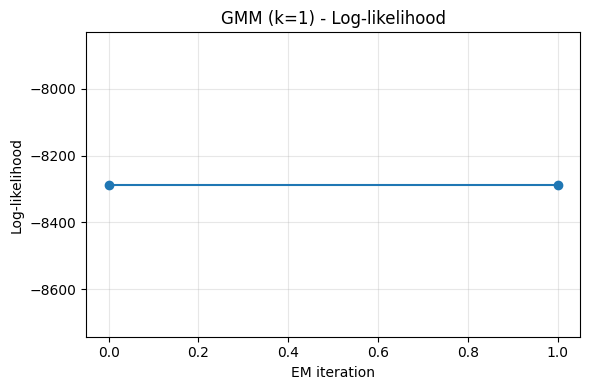

k=1	BIC=-8320.1771	logP(X|θ)=-8286.7541

iter: 20


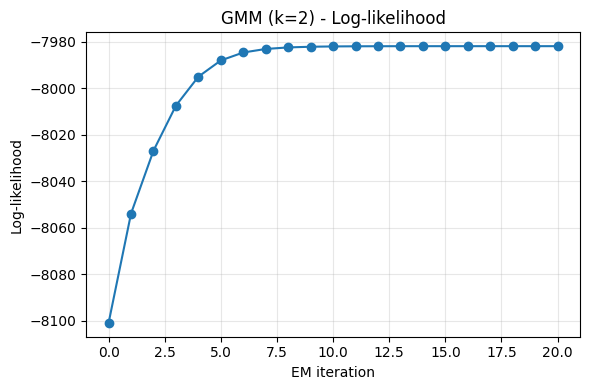

k=2	BIC=-8052.0417	logP(X|θ)=-7981.8532

iter: 17


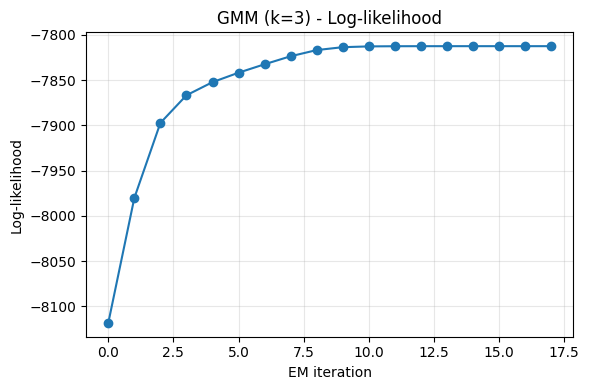

k=3	BIC=-7919.3844	logP(X|θ)=-7812.4306

iter: 20


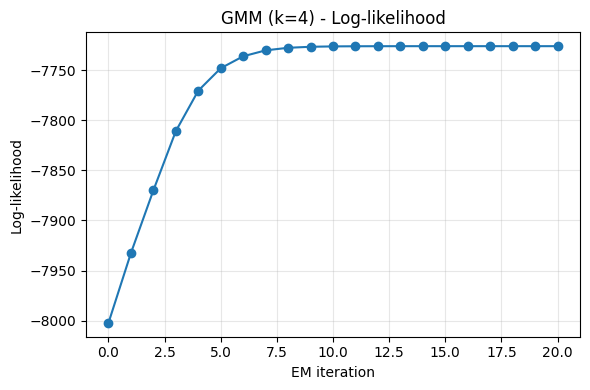

k=4	BIC=-7869.8688	logP(X|θ)=-7726.1497

iter: 46


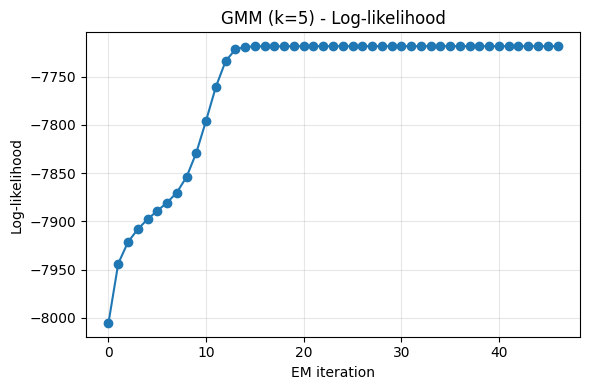

k=5	BIC=-7898.7322	logP(X|θ)=-7718.2477

iter max: 100 reached


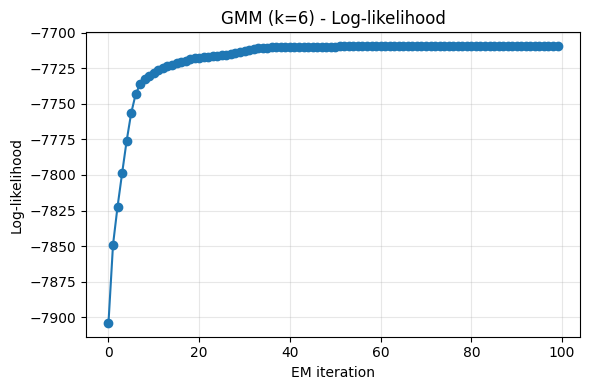

k=6	BIC=-7926.8059	logP(X|θ)=-7709.5560

Best model
k:		4
BIC:		-7869.8688
logP(X|θ):	-7726.1497


In [8]:
# load training set
train_df = pd.read_csv('train.csv')
print(f"train.csv loaded successfully. n={train_df.shape[0]}, d={train_df.shape[1]}")

# model selection using bayesian information score
seed_everything(9951)
candidate_categories = range(1, 7)
max_bic, best_k, best_gmm = -np.inf, None, None
for k in candidate_categories:
    gmm = GaussianMixtureModel(n_categories=k, n_features=train_df.shape[1])
    gmm.fit(train_df.values)
    ll = gmm.log_likelihood(train_df.values)
    bic_score = gmm.bic(train_df.values)
    print(f"k={k}\tBIC={bic_score:.4f}\tlogP(X|θ)={ll:.4f}")
    if bic_score > max_bic:
        max_bic = bic_score
        best_k = k
        best_gmm = gmm

# print training info
print()
print("Best model")
print(f"k:\t\t{best_k}")
print(f"BIC:\t\t{max_bic:.4f}")
print(f"logP(X|θ):\t{best_gmm.log_likelihood(train_df.values):.4f}")

### 4. Evaluation

To check if you did not break the API, you can use the training file to run the tests.

This is not meaningful for the evaluation of your model, as the true test set is hidden.

In [9]:
# If test.csv does not exist copy train into test
!test -f test.csv || cp train.csv test.csv

In [10]:
# load hidden test set ☠️
test_df = pd.read_csv('test.csv')
print(f"test.csv loaded successfully. n={test_df.shape[0]}, d={test_df.shape[1]}")

# print log-likelihood
test_log_likelihood = best_gmm.log_likelihood(test_df.values)
print(f"Log-likelihood of test data: {test_log_likelihood:.4f}")

# print parameters
print(f"k: {best_gmm.n_categories}")
print()
for cat_id in range(best_gmm.n_categories):
  print(f"π[{cat_id}]:", best_gmm._pi[cat_id])
  print(f"μ[{cat_id}]:", best_gmm._mu[cat_id])
  print(f"σ[{cat_id}]:", best_gmm._sigma[cat_id])
  print()

test.csv loaded successfully. n=800, d=5
Log-likelihood of test data: -7726.1497
k: 4

π[0]: 0.3234917442945391
μ[0]: [-2.76487659 -0.57500293 -0.45659567  2.05101651 -3.81371502]
σ[0]: [1.56470976 3.15747267 1.05200186 2.205698   1.56161587]

π[1]: 0.12069528452092738
μ[1]: [ 1.8792873   2.39719924 -0.19697045  0.26456917 -0.80136179]
σ[1]: [0.49249061 1.76528339 1.39092132 1.55283444 3.24692098]

π[2]: 0.12061816523572488
μ[2]: [-2.9487705  -1.75826876  0.81574653  2.46376901 -0.09864943]
σ[2]: [2.33168056 2.57814438 0.76242394 2.37040202 0.66044326]

π[3]: 0.4351948059488089
μ[3]: [-2.01544035  0.56098144 -2.33851178 -0.50666027 -0.10951374]
σ[3]: [2.56352305 2.24907832 1.23139759 1.64874539 2.78867145]

